# 01 Data audit

Load the raw file, print its real schema, check units, price formats, dates and missing values, then run the
documented cleaning rules and look at the funnel. Nothing here assumes column names: the mapping in
`config.COLUMN_ALIASES` is printed so it can be checked against the file.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from house_prices import clean, config, load

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
config.PATHS.figures_dir.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(config.PATHS.figures_dir / f"{name}.png", dpi=140, bbox_inches="tight")

## Load and inspect the raw file

In [2]:
raw = load.load_raw()
print(load.schema_report(raw))
print()
print(load.mapping_report(raw))
synthetic = load.is_synthetic(load.apply_schema(raw))
print()
print("Synthetic sample file:", synthetic)

Rows: 191,393
Columns: 17

Schema (dtype, non-null, distinct):
  property_id              int64      non-null=  191,393  distinct= 191,393
  location_id              int64      non-null=  191,393  distinct=   4,321
  page_url                 str        non-null=  191,393  distinct= 191,393
  property_type            str        non-null=  191,393  distinct=       7
  price                    int64      non-null=  191,393  distinct=   2,116
  location                 str        non-null=  191,393  distinct=   1,536
  city                     str        non-null=  191,393  distinct=       5
  province_name            str        non-null=  191,393  distinct=       3
  latitude                 float64    non-null=  191,393  distinct=   8,091
  longitude                float64    non-null=  191,393  distinct=   8,594
  baths                    int64      non-null=  191,393  distinct=      17
  area                     str        non-null=  191,393  distinct=     352
  purpose                

## Canonical view of the columns the project uses

In [3]:
canonical = load.apply_schema(raw)
canonical.drop(columns=["agency"]).head()

,listing_id,property_type,price,location,city,province,latitude,longitude,baths,bedrooms,area_text,area_size,area_unit,purpose,date_added
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,0,6 Kanal,<NA>,<NA>,For Sale,07-17-2019
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,5,1 Kanal,<NA>,<NA>,For Sale,10-06-2018
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,3,9 Marla,<NA>,<NA>,For Sale,07-03-2019
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,8,1 Kanal,<NA>,<NA>,For Sale,04-04-2019
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,6,11 Marla,<NA>,<NA>,For Sale,04-04-2019


## Purpose, property types and cities

Only `For Sale` listings are modelled; rentals are a different problem with different price scales.

In [4]:
print(canonical["purpose"].value_counts(dropna=False).to_string())
print()
print(canonical["property_type"].value_counts(dropna=False).to_string())
print()
print(canonical["city"].value_counts(dropna=False).to_string())

purpose
For Sale    127018
For Rent     64375

property_type
House            118915
Flat              40157
Upper Portion     18475
Lower Portion     11693
Room               1029
Farm House          725
Penthouse           399

city
Karachi       60484
Lahore        58736
Islamabad     40195
Rawalpindi    22898
Faisalabad     9080


## Area units and price formats

In [5]:
print(canonical["area_unit"].value_counts(dropna=False).to_string())
print()
text_prices = clean.units.count_text_prices(canonical["price"])
print(f"Price column dtype: {canonical['price'].dtype}; rows stored as text: {text_prices:,}")
if text_prices:
    display(canonical.loc[pd.to_numeric(canonical["price"], errors="coerce").isna(), "price"].head(10))

area_unit
<NA>    191393

Price column dtype: int64; rows stored as text: 0


## Dates

`date_added` is parsed month-first. If any value has a first component above 12 the assumption is wrong and
`clean.parse_dates` must be changed.

In [6]:
parsed_dates = clean.parse_dates(canonical["date_added"])
first_part = canonical["date_added"].astype(str).str.extract(r"^(\d+)[/-]", expand=False).astype(float)
print("Unparseable dates:", int(parsed_dates.isna().sum()))
print("Earliest:", parsed_dates.min(), " Latest:", parsed_dates.max())
print("Rows whose first component exceeds 12 (would contradict month-first):", int((first_part > 12).sum()))

Unparseable dates: 0
Earliest: 2018-08-05 00:00:00  Latest: 2019-08-06 00:00:00
Rows whose first component exceeds 12 (would contradict month-first): 0


## Missing values in the modelling columns

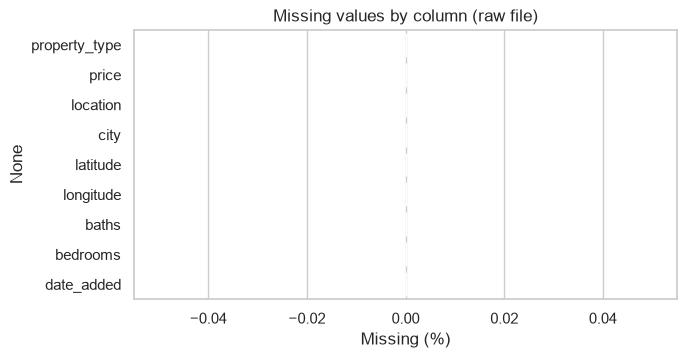

In [7]:
cols = ["property_type", "price", "location", "city", "latitude", "longitude", "baths", "bedrooms", "date_added"]
missing = canonical[cols].isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color="#4c78a8")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing values by column (raw file)")
save_fig(fig, "audit_missing")
plt.show()

## Run the cleaning rules

In [8]:
settings = config.CleaningSettings()
cleaned, funnel, info, parsed = clean.clean(canonical, settings)
funnel_df = pd.DataFrame(funnel)[["key", "removed", "modified", "remaining", "description"]]
display(funnel_df)
print()
print(f"Sq ft per Marla: {info['marla_sqft']:.2f} ({info['marla_source']})")
print(f"Raw rows {len(raw):,} -> cleaned rows {len(cleaned):,} ({len(cleaned) / len(raw):.1%})")

,key,removed,modified,remaining,description
0,raw,0,0,191393,Rows in the raw file
1,for_sale,64375,0,127018,Purpose is not 'For Sale' (rentals are a diffe...
2,price_present,2,0,127016,"Price missing, unparseable, zero or negative"
3,price_floor,76,0,126940,Price below the minimum plausible sale price (...
4,area_present,11,0,126929,"Area missing, unparseable, zero or negative"
5,area_bounds,11,0,126918,Area outside the plausible range in sq ft
6,categories_present,0,0,126918,"City, location or property type missing"
7,date_present,0,0,126918,date_added missing or unparseable
8,rooms_present,0,0,126918,Bedrooms or baths missing
9,zero_bedrooms,14232,0,112686,"Zero bedrooms on a house, flat or portion"



Sq ft per Marla: 272.25 (default 272.25 sq ft per Marla; the data has too few locations listing both Marla and sq ft/sq yd areas to infer a factor)
Raw rows 191,393 -> cleaned rows 67,073 (35.0%)


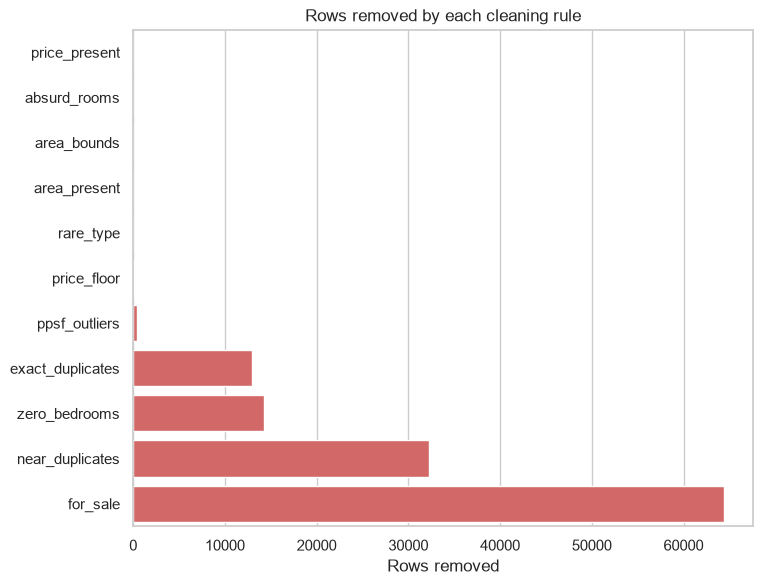

In [9]:
steps = funnel_df[funnel_df["removed"] > 0].sort_values("removed")
fig, ax = plt.subplots(figsize=(8, 0.45 * len(steps) + 1.5))
sns.barplot(x="removed", y="key", data=steps, ax=ax, color="#e45756")
ax.set_xlabel("Rows removed")
ax.set_ylabel("")
ax.set_title("Rows removed by each cleaning rule")
save_fig(fig, "audit_funnel")
plt.show()

## Price per sq ft before and after the outlier rule

The per-city IQR fence on log price per sq ft is applied last. The plot shows what it removes.

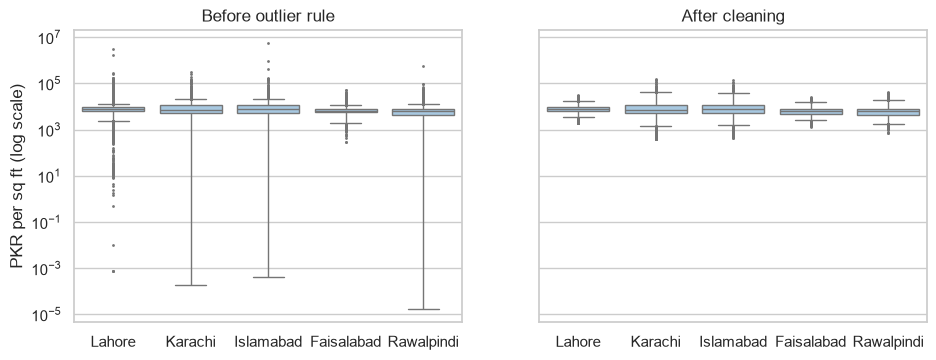

In [10]:
before = parsed[(parsed["purpose"] == config.PURPOSE_SALE) & (parsed["price"] > 0) & (parsed["area_sqft"] > 0)].copy()
before["ppsf"] = before["price"] / before["area_sqft"]
after = cleaned.assign(ppsf=cleaned["price"] / cleaned["area_sqft"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, frame, title in zip(axes, (before, after), ("Before outlier rule", "After cleaning")):
    sns.boxplot(data=frame, x="city", y="ppsf", ax=ax, color="#9ecae9", fliersize=1)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("")
axes[0].set_ylabel("PKR per sq ft (log scale)")
save_fig(fig, "audit_ppsf_before_after")
plt.show()

## Saved report

In [11]:
report = config.PATHS.data_quality_md
print(report.read_text(encoding="utf-8")[:1500] if report.exists() else "Run `python -m house_prices.clean` first.")

# Data quality report

Generated by `python -m house_prices.clean`. Do not edit by hand.

- Source file: `C:\Portfolio Projects\pakistan-house-prices\data\raw\pakistan_property.csv`
- SHA-256: `6ae4408d335619a2b0386721ea9512b00211fab8c5c7e76b93f50522331704f9`
- Raw rows: 191,393
- Cleaned rows: 67,073 (35.0%)

## Cleaning funnel

| Step | Rule | Rows removed | Rows modified | Rows remaining |
|---|---|---:|---:|---:|
| raw | Rows in the raw file | 0 | 0 | 191,393 |
| for_sale | Purpose is not 'For Sale' (rentals are a different problem) | 64,375 | 0 | 127,018 |
| price_present | Price missing, unparseable, zero or negative | 2 | 0 | 127,016 |
| price_floor | Price below the minimum plausible sale price (likely a rent, deposit or typo) | 76 | 0 | 126,940 |
| area_present | Area missing, unparseable, zero or negative | 11 | 0 | 126,929 |
| area_bounds | Area outside the plausible range in sq ft | 11 | 0 | 126,918 |
| categories_present | City, location or property type missing | 0 | 0 | 